In [ ]:
# SiT 클론
%cd /content
!git clone https://github.com/willisma/SiT.git

/content
Cloning into 'SiT'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 69 (delta 30), reused 9 (delta 9), pack-reused 24 (from 1)
Receiving objects: 100% (69/69), 5.92 MiB | 15.40 MiB/s, done.
Resolving deltas: 100% (30/30), done.


In [ ]:
# REPA와 REG에서 필요한 패키지들도 함께 호환되도록 설치
!pip install -q timm diffusers accelerate einops torchdiffeq
!pip install -q "huggingface-hub>=1.5.0,<2.0"

In [ ]:
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch Version: 2.11.0+cu130
CUDA Available: True
GPU: Tesla T4
VRAM: 15.64 GB


In [ ]:
%cd /content/SiT
# SiT-XL/2 (256x256) 모델 가중치 자동 다운로드
!python sample.py ODE --image-size 256 --seed 42

/content/SiT
100% 2.70G/2.70G [02:00<00:00, 22.4MB/s]
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
config.json: 100% 547/547 [00:00<00:00, 1.37MB/s]

diffusion_pytorch_model.safetensors: downloading bytes:  91% 305M/335M [00:02<00:00, 164MB/s, 26.7MB/s  ]
diffusion_pytorch_model.safetensors: reconstructing file:  80% 268M/335M [00:02<00:00, 101MB/s]
diffusion_pytorch_model.safetensors: downloading bytes: 100% 316M/316M [00:04<00:00, 66.9MB/s, 27.7MB/s  ]
diffusion_pytorch_model.safetensors: reconstructing file: 100% 335M/335M [00:04<00:00, 70.9MB/s, 26.6MB/s  ]
Sampling took 114.32 seconds.


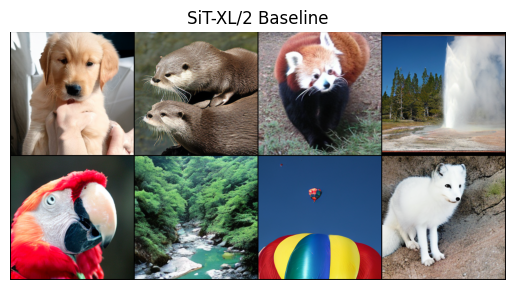

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import glob

sample_images = glob.glob("/content/SiT/**/*.png", recursive=True)
if sample_images:
    img = Image.open(sample_images[0])
    plt.imshow(img)
    plt.axis('off')
    plt.title("SiT-XL/2 Baseline")
    plt.show()
else:
    print("생성된 이미지를 찾을 수 없습니다.")

In [ ]:
%cd /content
!git clone https://github.com/sihyun-yu/REPA.git
%cd /content/REPA
# REPA용 추가 요구사항 설치 (SiT와 겹치는 부분은 건너뜀)
!pip install -r requirements.txt

/content
Cloning into 'REPA'...
remote: Enumerating objects: 186, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 186 (delta 49), reused 35 (delta 35), pack-reused 117 (from 1)
Receiving objects: 100% (186/186), 7.54 MiB | 26.71 MiB/s, done.
Resolving deltas: 100% (91/91), done.
/content/REPA
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-4bkw7bex
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-4bkw7bex
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369549 sha256=6ad9de7a4e6ef48ba34415fe57aa60821f92bfec07f1b15a924ce9a9f8f07424
  Stored in directory: /tmp/pip-ephem-wheel-cache-jhpgio3l/wheels/cb/a8/74/5f32d6cf

In [ ]:
%cd /content/REPA
# DINOv2-ViT-B를 사용하는 SiT-XL/2 REPA 체크포인트가 자동 다운로드됩니다.
# (Colab T4이므로 nproc_per_node=1 로 설정)
!torchrun --nnodes=1 --nproc_per_node=1 generate.py \
  --model SiT-XL/2 \
  --num-fid-samples 4 \
  --path-type=linear \
  --encoder-depth=8 \
  --projector-embed-dims=768 \
  --per-proc-batch-size=4 \
  --mode=sde \
  --num-steps=250 \
  --cfg-scale=1.8 \
  --guidance-high=0.7

/content/REPA
Starting rank=0, seed=0, world_size=1.
100% 2.73G/2.73G [01:32<00:00, 29.7MB/s]
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
config.json: 100% 547/547 [00:00<00:00, 2.56MB/s]

diffusion_pytorch_model.safetensors: downloading bytes:  71% 236M/335M [00:02<00:00, 214MB/s, 18.7MB/s  ]
diffusion_pytorch_model.safetensors: downloading bytes:  93% 310M/335M [00:02<00:00, 150MB/s, 27.1MB/s  ]
diffusion_pytorch_model.safetensors: downloading bytes: 100% 316M/316M [00:03<00:00, 96.0MB/s, 27.7MB/s  ]
diffusion_pytorch_model.safetensors: reconstructing file: 100% 335M/335M [00:03<00:00, 102MB/s, 30.3MB/s  ]
Saving .png samples at samples/SiT-XL-2-SiT-XL-2-256x256-size-256-vae-ema-cfg-1.8-seed-0-sde
/usr/local/lib/python3.13/dist-packages/torch/distributed/c10d_logger.py:

In [ ]:
%cd /content
!git clone https://github.com/Martinser/REG.git || echo "REG already exists"
%cd /content/REG
!pip show huggingface_hub | head -2
!pip install -q "huggingface_hub>=1.5.0,<2.0"
!pip show huggingface_hub | head -2

/content
Cloning into 'REG'...
remote: Enumerating objects: 156, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 156 (delta 36), reused 25 (delta 25), pack-reused 79 (from 1)
Receiving objects: 100% (156/156), 5.56 MiB | 20.33 MiB/s, done.
Resolving deltas: 100% (60/60), done.
/content/REG
Name: huggingface_hub
Version: 1.33.0
ERROR: Pipe to stdout was broken
Exception ignored on flushing sys.stdout:
BrokenPipeError: [Errno 32] Broken pipe
Name: huggingface_hub
Version: 1.33.0
ERROR: Pipe to stdout was broken
Exception ignored on flushing sys.stdout:
BrokenPipeError: [Errno 32] Broken pipe


In [ ]:
!hf download Martinser/REG --local-dir ./ckpts

Hint: A new version of huggingface_hub (2.1.1) is available! You are using version 1.33.0.
To update, run: hf update
Hint: The `hf-cli` skill is not installed. Run `hf skills add -g` to teach your AI agents how to use the `hf` CLI.
Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0% 0/4 [00:00<?, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.

Reconstructing (incomplete total...):   0% 0.00/21.9G [00:00<?, ?B/s]         
Reconstructing (incomplete total...):   0% 1.58k/21.9G [00:00<1144:48:04, 5.32kB/s]
Reconstructing (incomplete total...):   0% 1.58k/21.9G [00:00<1144:48:04, 5.32kB/s]

Fetching 4 files:  25% 1/4 [00:00<00:00,  3.31it/s]
Reconstructing (incomplete total...):  22% 4.76G/21.9G [01:10<05:41, 50.2MB/s, 50.2MB/s  ]
Reconstructing (incomplete total...):  27% 5.97G/21.9G [01:50<07:50, 33.9MB/s, 33.9MB/s  ]
Reconstructing (incomple

In [ ]:
%cd /content/REG
!sed -i "s/torch.load(ckpt_path, map_location=f'cuda:{device}')\['ema'\]/torch.load(ckpt_path, map_location=f'cuda:{device}', weights_only=False)\['ema'\]/g" generate.py
print("generate.py 파일 수정이 완료되었습니다!")
!torchrun --nnodes=1 --nproc_per_node=1 generate.py \
--model SiT-XL/2 \
--num-fid-samples 4 \
--path-type=linear \
--encoder-depth=8 \
--projector-embed-dims=768 \
--per-proc-batch-size=4 \
--mode=sde \
--num-steps=250 \
--cfg-scale=1.8 \
--guidance-high=0.7 \
--ckpt ./ckpts/REG-XLarge-256/4000000.pt

/content/REG
generate.py 파일 수정이 완료되었습니다!
Starting rank=0, seed=0, world_size=1.
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Saving .png samples at samples/SiT-XL-2-4000000-size-256-vae-ema-cfg-1.8-seed-0-sde-0.7-1.5
/usr/local/lib/python3.13/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)
[rank0]:[W1006 13:50:02.638734407 ProcessGroupNCCL.cpp:5188] Guessing device ID based on global rank. This can cause a hang if rank to GPU mapping is heterogeneous. You can specify device_id in init_process_group()
Total number of images that will be sampled: 4
SiT Parameters: 685,017,360
projector Parameters: 8,131,32

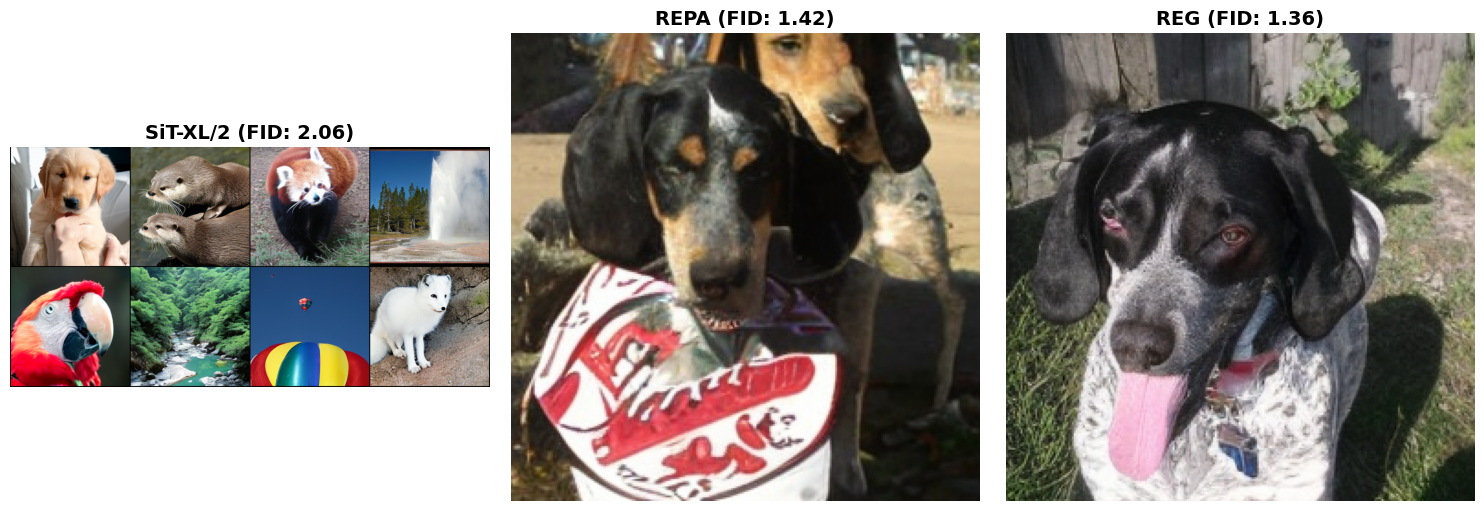

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# 각 레포에서 생성된 샘플 이미지 경로
sit_path = "/content/SiT/sample.png"
repa_path = "/content/REPA/samples/SiT-XL-2-SiT-XL-2-256x256-size-256-vae-ema-cfg-1.8-seed-0-sde/000000.png"
reg_path = "/content/REG/samples/SiT-XL-2-4000000-size-256-vae-ema-cfg-1.8-seed-0-sde-0.7-1.5/000000.png"

paths = [sit_path, repa_path, reg_path]
titles = ["SiT-XL/2 (FID: 2.06)", "REPA (FID: 1.42)", "REG (FID: 1.36)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, path, title in zip(axes, paths, titles):
    try:
        img = Image.open(path)
        ax.imshow(img)
    except FileNotFoundError:
        ax.text(0.5, 0.5, 'Image Not Found\n(OOM or Path Error)',
                ha='center', va='center')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# [Toy 실험 1/5] 환경 정리 + Toy 데이터 생성 (학습용 40장 / held-out 평가용 40장)
import os, torchvision
from PIL import Image

# 이전 셀에서 오프라인 모드가 켜져 있었다면 해제
os.environ.pop("HF_HUB_OFFLINE", None)

# diffusers/transformers가 요구하는 huggingface_hub 범위로 고정
!pip install -q "huggingface_hub>=1.5.0,<2.0"

def make_toy_split(cifar, out_dir, classes, n_per_class=10):
    counts = {c: 0 for c in classes}
    for img, label in cifar:
        if label in classes and counts[label] < n_per_class:
            d = os.path.join(out_dir, classes[label])
            os.makedirs(d, exist_ok=True)
            img.resize((256, 256), Image.BICUBIC).save(f"{d}/{counts[label]:03d}.png")
            counts[label] += 1
        if all(v >= n_per_class for v in counts.values()):
            break

classes = {0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat'}
cifar_train = torchvision.datasets.CIFAR10(root='/content/cifar_raw', train=True, download=True)
cifar_test = torchvision.datasets.CIFAR10(root='/content/cifar_raw', train=False, download=True)

make_toy_split(cifar_train, '/content/SiT/toy_data', classes)   # 학습용 40장 (CIFAR-10 train)
make_toy_split(cifar_test, '/content/SiT/toy_eval', classes)    # held-out 평가용 40장 (CIFAR-10 test, 학습에 미사용)

for d in ['toy_data', 'toy_eval']:
    root = f'/content/SiT/{d}'
    n = sum(len(f) for _, _, f in os.walk(root))
    print(f"{d}: {n}장", sorted(os.listdir(root)))


100%|██████████| 170M/170M [27:52<00:00, 102kB/s] 


toy_data: 40장 ['airplane', 'automobile', 'bird', 'cat']
toy_eval: 40장 ['airplane', 'automobile', 'bird', 'cat']


In [ ]:
%%writefile /content/SiT/train_align.py
# SiT 학습 스크립트 (단일 GPU) + 선택적 REPA식 정렬 loss + held-out 평가
import os, csv, argparse
from time import time
import numpy as np
import torch
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
import torch.nn as nn
import torch.nn.functional as F
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import DataLoader
from torch.utils.data.distributed import DistributedSampler
from torchvision.datasets import ImageFolder
from torchvision import transforms
from PIL import Image
from diffusers.models import AutoencoderKL

from models import SiT_models
from transport import create_transport
from train_utils import parse_transport_args


def center_crop_arr(pil_image, image_size):
    while min(*pil_image.size) >= 2 * image_size:
        pil_image = pil_image.resize(tuple(x // 2 for x in pil_image.size), resample=Image.BOX)
    scale = image_size / min(*pil_image.size)
    pil_image = pil_image.resize(tuple(round(x * scale) for x in pil_image.size), resample=Image.BICUBIC)
    arr = np.array(pil_image)
    cy = (arr.shape[0] - image_size) // 2
    cx = (arr.shape[1] - image_size) // 2
    return Image.fromarray(arr[cy:cy + image_size, cx:cx + image_size])


def main(args):
    assert torch.cuda.is_available(), "GPU required"
    dist.init_process_group("gloo")          # single-GPU Colab
    rank, world = dist.get_rank(), dist.get_world_size()
    device = rank % torch.cuda.device_count()
    torch.manual_seed(args.global_seed * world + rank)
    torch.cuda.set_device(device)
    local_bs = args.global_batch_size // world

    exp_name = args.exp_name or f"{'align' if args.align else 'base'}-seed{args.global_seed}"
    exp_dir = os.path.join(args.results_dir, exp_name)
    os.makedirs(exp_dir, exist_ok=True)
    csv_f = open(os.path.join(exp_dir, "metrics.csv"), "w", newline="")
    writer = csv.writer(csv_f)
    writer.writerow(["step", "l_simple", "l_align", "total"])
    eval_f = open(os.path.join(exp_dir, "eval.csv"), "w", newline="")
    eval_writer = csv.writer(eval_f)
    eval_writer.writerow(["step", "train_fixed", "heldout"])

    # ---- model ----
    latent_size = args.image_size // 8
    model = SiT_models[args.model](input_size=latent_size, num_classes=args.num_classes).to(device)
    hidden = model.pos_embed.shape[-1]
    n_tokens = model.pos_embed.shape[1]

    feats = {}
    projector, encoder = None, None
    params = list(model.parameters())
    if args.align:
        from transformers import Dinov2Model
        encoder = Dinov2Model.from_pretrained(args.dino).to(device).eval()
        for p in encoder.parameters():
            p.requires_grad = False
        z_dim = encoder.config.hidden_size
        # projector 초기화가 전역 RNG를 소비하지 않도록 (baseline과 노이즈 샘플링 동일하게 유지)
        with torch.random.fork_rng(devices=[]):
            projector = nn.Sequential(
                nn.Linear(hidden, args.proj_hidden), nn.SiLU(),
                nn.Linear(args.proj_hidden, args.proj_hidden), nn.SiLU(),
                nn.Linear(args.proj_hidden, z_dim),
            )
        projector = projector.to(device)
        params += list(projector.parameters())
        model.blocks[args.encoder_depth - 1].register_forward_hook(
            lambda m, i, o: feats.__setitem__("h", o))
        mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

    model = DDP(model, device_ids=[device])
    transport = create_transport(args.path_type, args.prediction, args.loss_weight,
                                 args.train_eps, args.sample_eps)
    vae = AutoencoderKL.from_pretrained(f"stabilityai/sd-vae-ft-{args.vae}").to(device)
    opt = torch.optim.AdamW(params, lr=1e-4, weight_decay=0)

    # ---- data ----
    transform = transforms.Compose([
        transforms.Lambda(lambda im: center_crop_arr(im, args.image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5] * 3, std=[0.5] * 3, inplace=True),
    ])
    eval_transform = transforms.Compose([       # 평가용: flip 없음
        transforms.Lambda(lambda im: center_crop_arr(im, args.image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5] * 3, std=[0.5] * 3, inplace=True),
    ])
    dataset = ImageFolder(args.data_path, transform=transform)
    sampler = DistributedSampler(dataset, num_replicas=world, rank=rank, shuffle=True, seed=args.global_seed)
    loader = DataLoader(dataset, batch_size=local_bs, shuffle=False, sampler=sampler,
                        num_workers=args.num_workers, pin_memory=True, drop_last=True)
    print(f"[{exp_name}] {args.model}, align={args.align}, train_images={len(dataset)}, "
          f"tokens={n_tokens}, seed={args.global_seed}", flush=True)

    # ---- 고정 평가셋: latent를 한 번만 만들어 재사용 (학습 난수 순서에 영향 없도록 RNG 격리) ----
    @torch.no_grad()
    def build_eval_set(folder):
        ds = ImageFolder(folder, transform=eval_transform)
        dl = DataLoader(ds, batch_size=20, shuffle=False, num_workers=0)
        xs, ys = [], []
        with torch.random.fork_rng(devices=[device]):
            torch.manual_seed(args.eval_seed)
            for img, y in dl:
                xs.append(vae.encode(img.to(device)).latent_dist.sample().mul_(0.18215))
                ys.append(y.to(device))
        return torch.cat(xs), torch.cat(ys)

    train_x, train_y = build_eval_set(args.data_path)     # 학습에 쓴 40장 (고정 노이즈로 재측정)
    held_x, held_y = build_eval_set(args.eval_path)       # 학습에 쓰지 않은 40장

    @torch.no_grad()
    def evaluate(ex, ey):
        """고정 노이즈/t 로 L_simple 을 측정. 전역 RNG 상태는 복원된다."""
        model.eval()
        losses = []
        with torch.random.fork_rng(devices=[device]):
            torch.manual_seed(args.eval_seed)
            for _ in range(args.eval_repeats):
                for i in range(0, ex.shape[0], args.eval_batch):
                    xb, yb = ex[i:i + args.eval_batch], ey[i:i + args.eval_batch]
                    losses.append(transport.training_losses(model, xb, dict(y=yb))["loss"].mean().item())
        model.train()
        return float(np.mean(losses))

    def run_eval(step):
        tr, ho = evaluate(train_x, train_y), evaluate(held_x, held_y)
        eval_writer.writerow([step, tr, ho])
        eval_f.flush()
        print(f"[{exp_name}] step={step:05d} EVAL train_fixed={tr:.4f} heldout={ho:.4f}", flush=True)

    @torch.no_grad()
    def dino_patch_feats(img):
        x = (img + 1) / 2
        x = F.interpolate(x, size=224, mode="bicubic", align_corners=False)
        x = (x - mean) / std
        return encoder(pixel_values=x).last_hidden_state[:, 1:]   # patch tokens (B, 256, z_dim)

    model.train()
    run_eval(0)
    step, t0 = 0, time()
    for epoch in range(args.epochs):
        sampler.set_epoch(epoch)
        for img, y in loader:
            img, y = img.to(device), y.to(device)
            with torch.no_grad():
                x = vae.encode(img).latent_dist.sample().mul_(0.18215)
            l_simple = transport.training_losses(model, x, dict(y=y))["loss"].mean()

            if args.align:
                z = dino_patch_feats(img)
                z_tilde = projector(feats["h"])
                assert z_tilde.shape[1] == z.shape[1], \
                    f"token mismatch: SiT {z_tilde.shape[1]} vs DINOv2 {z.shape[1]} (SiT-S/2 필요)"
                l_align = -F.cosine_similarity(z_tilde, z, dim=-1).mean()
                loss = l_simple + args.align_lambda * l_align
            else:
                l_align = torch.zeros((), device=device)
                loss = l_simple

            opt.zero_grad()
            loss.backward()
            opt.step()

            step += 1
            writer.writerow([step, l_simple.item(), l_align.item(), loss.item()])
            if step % args.log_every == 0:
                csv_f.flush()
                print(f"[{exp_name}] step={step:05d} L_simple={l_simple.item():.4f} "
                      f"L_align={l_align.item():.4f} ({step / (time() - t0):.2f} it/s)", flush=True)
            if step % args.eval_every == 0:
                run_eval(step)

    csv_f.close()
    eval_f.close()
    print(f"[{exp_name}] Done!", flush=True)
    dist.destroy_process_group()


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-path", type=str, required=True)
    parser.add_argument("--eval-path", type=str, required=True)
    parser.add_argument("--results-dir", type=str, default="results_cmp")
    parser.add_argument("--exp-name", type=str, default=None)
    parser.add_argument("--model", type=str, choices=list(SiT_models.keys()), default="SiT-S/2")
    parser.add_argument("--image-size", type=int, default=256)
    parser.add_argument("--num-classes", type=int, default=4)
    parser.add_argument("--epochs", type=int, default=30)
    parser.add_argument("--global-batch-size", type=int, default=4)
    parser.add_argument("--global-seed", type=int, default=0)
    parser.add_argument("--vae", type=str, choices=["ema", "mse"], default="ema")
    parser.add_argument("--num-workers", type=int, default=2)
    parser.add_argument("--log-every", type=int, default=50)
    # 평가
    parser.add_argument("--eval-every", type=int, default=25)
    parser.add_argument("--eval-seed", type=int, default=1234)
    parser.add_argument("--eval-repeats", type=int, default=4)
    parser.add_argument("--eval-batch", type=int, default=20)
    # 정렬 (REPA-style)
    parser.add_argument("--align", action="store_true")
    parser.add_argument("--align-lambda", type=float, default=0.5)
    parser.add_argument("--encoder-depth", type=int, default=8)
    parser.add_argument("--proj-hidden", type=int, default=2048)
    parser.add_argument("--dino", type=str, default="facebook/dinov2-small")
    parse_transport_args(parser)
    main(parser.parse_args())


Writing /content/SiT/train_align.py


In [ ]:
# [Toy 실험 3/5] 베이스라인 vs 정렬(REPA-style) 학습 실행 (SiT-S/2, 시드 3개)
import os
os.chdir('/content/SiT')
os.environ.pop("HF_HUB_OFFLINE", None)

SEEDS = [0, 1, 2]
common = ("--model SiT-S/2 --data-path toy_data --eval-path toy_eval --image-size 256 --num-classes 4 "
          "--global-batch-size 4 --epochs 30 --num-workers 2 --log-every 50 --eval-every 25 "
          "--results-dir results_cmp")

!rm -rf results_cmp
for s in SEEDS:
    !torchrun --nnodes=1 --nproc_per_node=1 train_align.py {common} --global-seed {s} --exp-name base-seed{s}
    !torchrun --nnodes=1 --nproc_per_node=1 train_align.py {common} --global-seed {s} --exp-name align-seed{s} --align


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
[base-seed0] SiT-S/2, align=False, train_images=40, tokens=256, seed=0
[base-seed0] step=00000 EVAL train_fixed=2.0955 heldout=2.1350
[base-seed0] step=00025 EVAL train_fixed=1.7925 heldout=1.8260
[base-seed0] step=00050 L_simple=1.6082 L_align=0.0000 (2.02 it/s)
[base-seed0] step=00050 EVAL train_fixed=1.6434 heldout=1.6649
[base-seed0] step=00075 EVAL train_fixed=1.5423 heldout=1.5526
[base-seed0] step=00100 L_simple=1.3718 L_align=0.0000 (1.99 it/s)
[base-seed0] step=00100 EVAL train_fixed=1.4236 heldout=1.4310
[base-seed0] step=00125 EVAL train_fixed=1.2036 heldout=1.2030
[base-seed0] step=00150 L_simple=1.2246 L_align=0.0000 (1.96 it/s)
[base-seed0] step=00150 EVAL train_fixed=1.1000 heldout=1.0968
[base-seed0] step=00175 E

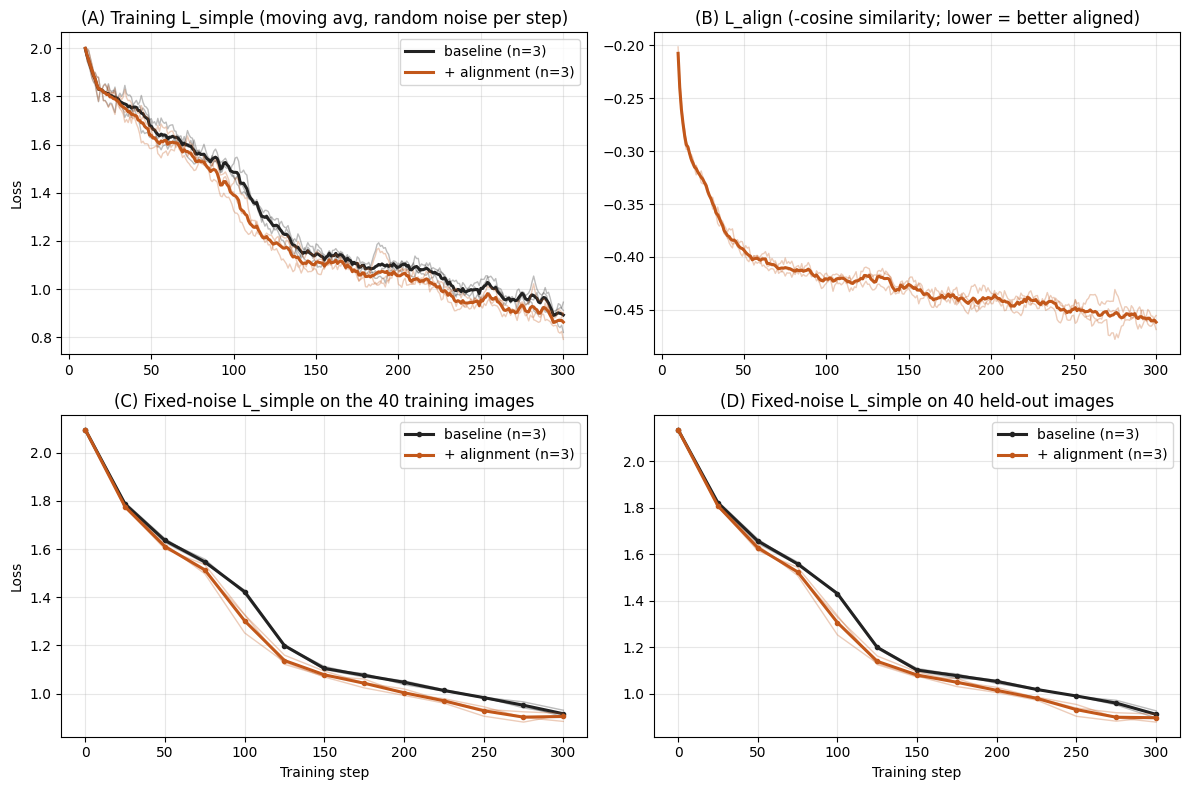

== 고정 노이즈 평가 (step 250~300 평균) ==
train_fixed  baseline 0.9505 | align 0.9121 | 시드별 (baseline - align): [0.0461 0.0345 0.0346]
heldout      baseline 0.9528 | align 0.9082 | 시드별 (baseline - align): [0.0582 0.0366 0.0391]
일반화 격차 (heldout - train): baseline 0.0023 | align -0.0039
step 0 (초기) heldout: baseline 2.1350

== 학습 중 L_simple (step 51~300 평균, 기존 방식) ==
시드별 (baseline - align): [0.0638 0.0373 0.0387]  평균: 0.0466


In [ ]:
# [Toy 실험 4/5] 결과 비교: 학습 loss + 고정 노이즈 평가(학습셋 / held-out)
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE, ALIGN = "#222222", "#C2571A"
root = "/content/SiT/results_cmp"

def load(tag, name):
    return [pd.read_csv(p) for p in sorted(glob.glob(f"{root}/{tag}-seed*/{name}"))]

def smooth(y, w=10):
    return np.convolve(y, np.ones(w) / w, mode="valid")

m_base, m_align = load("base", "metrics.csv"), load("align", "metrics.csv")
e_base, e_align = load("base", "eval.csv"), load("align", "eval.csv")
assert len(m_base) and len(m_align), "results_cmp 에 결과가 없습니다. 위 학습 셀을 먼저 실행하세요."

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (A) 학습 중 L_simple (스텝별 값의 이동평균)
w = 10
ax = axes[0, 0]
for runs, color, label in [(m_base, BASE, "baseline"), (m_align, ALIGN, "+ alignment")]:
    ys = np.stack([r["l_simple"].values for r in runs])
    steps = runs[0]["step"].values
    for y in ys:
        ax.plot(steps[w - 1:], smooth(y, w), color=color, alpha=0.3, lw=1)
    ax.plot(steps[w - 1:], smooth(ys.mean(0), w), color=color, lw=2.2, label=f"{label} (n={len(runs)})")
ax.set_title("(A) Training L_simple (moving avg, random noise per step)")
ax.set_ylabel("Loss"); ax.legend(); ax.grid(alpha=0.3)

# (B) 정렬 loss
ax = axes[0, 1]
ya = np.stack([r["l_align"].values for r in m_align])
steps = m_align[0]["step"].values
for y in ya:
    ax.plot(steps[w - 1:], smooth(y, w), color=ALIGN, alpha=0.3, lw=1)
ax.plot(steps[w - 1:], smooth(ya.mean(0), w), color=ALIGN, lw=2.2)
ax.set_title("(B) L_align (-cosine similarity; lower = better aligned)")
ax.grid(alpha=0.3)

# (C), (D) 고정 노이즈로 측정한 L_simple
for ax, col, title in [(axes[1, 0], "train_fixed", "(C) Fixed-noise L_simple on the 40 training images"),
                       (axes[1, 1], "heldout", "(D) Fixed-noise L_simple on 40 held-out images")]:
    for runs, color, label in [(e_base, BASE, "baseline"), (e_align, ALIGN, "+ alignment")]:
        ys = np.stack([r[col].values for r in runs])
        steps = runs[0]["step"].values
        for y in ys:
            ax.plot(steps, y, color=color, alpha=0.3, lw=1)
        ax.plot(steps, ys.mean(0), color=color, lw=2.2, marker="o", ms=3, label=f"{label} (n={len(runs)})")
    ax.set_title(title); ax.set_xlabel("Training step"); ax.grid(alpha=0.3); ax.legend()
axes[1, 0].set_ylabel("Loss")

plt.tight_layout()
plt.savefig("/content/SiT/toy_compare.png", dpi=150)
plt.show()

# ---- 수치 요약 (마지막 3회 평가 = step 250/275/300 평균) ----
def last(runs, col, k=3):
    return np.array([r[col].values[-k:].mean() for r in runs])

print("== 고정 노이즈 평가 (step 250~300 평균) ==")
for col in ["train_fixed", "heldout"]:
    b, a = last(e_base, col), last(e_align, col)
    print(f"{col:12s} baseline {b.mean():.4f} | align {a.mean():.4f} | 시드별 (baseline - align): {np.round(b - a, 4)}")
gap_b = last(e_base, "heldout") - last(e_base, "train_fixed")
gap_a = last(e_align, "heldout") - last(e_align, "train_fixed")
print(f"일반화 격차 (heldout - train): baseline {gap_b.mean():.4f} | align {gap_a.mean():.4f}")
print(f"step 0 (초기) heldout: baseline {np.mean([r['heldout'].values[0] for r in e_base]):.4f}")

print("\n== 학습 중 L_simple (step 51~300 평균, 기존 방식) ==")
d = [(b["l_simple"].values - a["l_simple"].values)[50:].mean() for b, a in zip(m_base, m_align)]
print("시드별 (baseline - align):", np.round(d, 4), " 평균:", round(float(np.mean(d)), 4))


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# [Toy 실험 5/5] 결과 저장
!cd /content/SiT && zip -rq toy_results.zip results_cmp toy_compare.png train_align.py
from google.colab import files
files.download('/content/SiT/toy_results.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>